# India Tech Job Market Analysis
## Step 5 — Python Skills Analysis

This notebook analyzes the `Skills_Required` field, including overall skill demand, Data Analyst skills, skill combinations, salary by skill, and exports results for later Power BI work.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from itertools import combinations
from pathlib import Path

df = pd.read_csv(Path("india_job_market_2024_2026_cleaned.csv"))
print("Dataset loaded:", df.shape)
display(df.head())

Dataset loaded: (5000, 23)


,Job_ID,Job_Title,Company,Company_Type,Industry,City,Location_Tier,Experience_Level,Job_Type,Work_Mode,...,Openings,Applicants,Company_Rating,Date_Posted,Applicants_per_Opening,Year,Month,Year_Month,Skill_Count,Salary_Anomaly_Flag
0,IND2025000,Android Developer,Tech Mahindra,MNC,Information Technology,Remote,Remote,Senior (6-10 yrs),Full-Time,Remote,...,3,276,4.0,2025-10-31,92.000000,2025,10,2025-10,3,False
1,IND2025001,QA Engineer,Dream11,Indian Unicorn,Information Technology,Lucknow,Tier 2,Senior (6-10 yrs),Full-Time,Hybrid,...,3,325,4.0,2025-05-19,108.333333,2025,5,2025-05,5,False
2,IND2025002,Business Analyst,HAL,PSU/Govt,EdTech,Remote,Remote,Senior (6-10 yrs),Full-Time,Remote,...,5,559,3.6,2024-08-21,111.800000,2024,8,2024-08,3,False
3,IND2025003,Cybersecurity Analyst,Groww,Startup,Information Technology,Mumbai,Tier 1,Mid (3-6 yrs),Full-Time,Hybrid,...,3,184,3.5,2026-03-18,61.333333,2026,3,2026-03,5,False
4,IND2025004,Python Developer,Oracle,MNC,EdTech,Remote,Remote,Junior (1-3 yrs),Full-Time,Remote,...,1,64,3.9,2024-10-25,64.000000,2024,10,2024-10,4,False


## 1. Extract individual skills

In [2]:
all_skills = []

for skills in df["Skills_Required"].dropna():
    all_skills.extend([s.strip() for s in str(skills).split(",") if s.strip()])

skill_counts = Counter(all_skills)

top_20_skills = pd.DataFrame(
    skill_counts.most_common(20),
    columns=["Skill", "Job_Count"]
)

print("Unique skills:", len(skill_counts))
display(top_20_skills)

Unique skills: 109


,Skill,Job_Count
0,Python,1579
1,REST APIs,998
2,AWS,867
3,SQL,847
4,Docker,836
5,Java,636
6,PostgreSQL,455
7,React,454
8,TypeScript,440
9,Agile,429


## 2. Top 10 most demanded skills

,Skill,Job_Count
0,Python,1579
1,REST APIs,998
2,AWS,867
3,SQL,847
4,Docker,836
5,Java,636
6,PostgreSQL,455
7,React,454
8,TypeScript,440
9,Agile,429


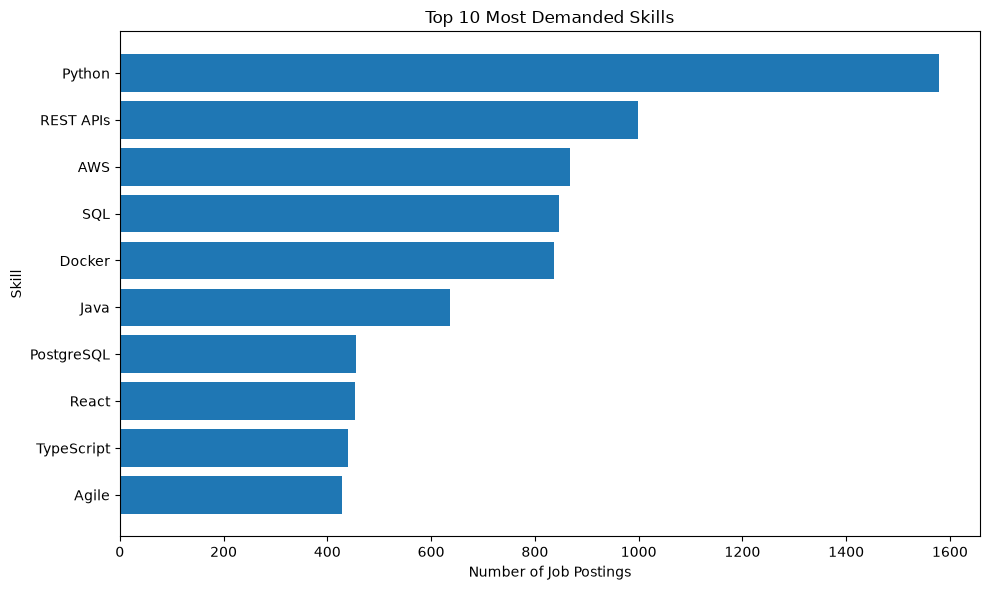

In [3]:
top_10_skills = top_20_skills.head(10)
display(top_10_skills)

plt.figure(figsize=(10, 6))
plt.barh(top_10_skills["Skill"][::-1], top_10_skills["Job_Count"][::-1])
plt.xlabel("Number of Job Postings")
plt.ylabel("Skill")
plt.title("Top 10 Most Demanded Skills")
plt.tight_layout()
plt.show()

## 3. Skills required per job

count    5000.000000
mean        4.505000
std         1.123489
min         3.000000
25%         3.000000
50%         5.000000
75%         6.000000
max         6.000000
Name: Skill_Count, dtype: float64

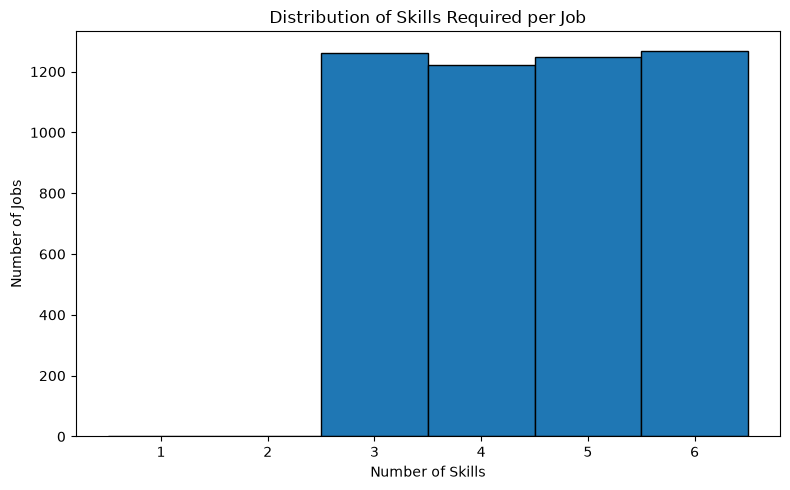

In [4]:
display(df["Skill_Count"].describe())

plt.figure(figsize=(8, 5))
plt.hist(df["Skill_Count"], bins=np.arange(1, 8) - 0.5, edgecolor="black")
plt.xlabel("Number of Skills")
plt.ylabel("Number of Jobs")
plt.title("Distribution of Skills Required per Job")
plt.xticks(range(1, 7))
plt.tight_layout()
plt.show()

## 4. Skill demand by experience level

In [5]:
rows = []

for experience in df["Experience_Level"].dropna().unique():
    counter = Counter()
    subset = df[df["Experience_Level"] == experience]
    for skills in subset["Skills_Required"].dropna():
        counter.update([s.strip() for s in str(skills).split(",") if s.strip()])
    for skill, count in counter.items():
        rows.append([experience, skill, count])

experience_skill_df = pd.DataFrame(
    rows, columns=["Experience_Level", "Skill", "Job_Count"]
).sort_values(["Experience_Level", "Job_Count"], ascending=[True, False])

display(experience_skill_df.head(40))

,Experience_Level,Skill,Job_Count
331,Fresher (0-1 yr),Python,320
327,Fresher (0-1 yr),REST APIs,202
369,Fresher (0-1 yr),Docker,177
343,Fresher (0-1 yr),AWS,176
337,Fresher (0-1 yr),SQL,166
381,Fresher (0-1 yr),Java,142
359,Fresher (0-1 yr),TypeScript,94
372,Fresher (0-1 yr),PostgreSQL,92
370,Fresher (0-1 yr),MongoDB,90
352,Fresher (0-1 yr),Agile,87


## 5. Top skills for Data Analyst jobs

In [6]:
data_analyst_df = df[
    df["Job_Title"].str.strip().str.lower() == "data analyst"
].copy()

data_analyst_skills = Counter()

for skills in data_analyst_df["Skills_Required"].dropna():
    data_analyst_skills.update([s.strip() for s in str(skills).split(",") if s.strip()])

data_analyst_top_skills = pd.DataFrame(
    data_analyst_skills.most_common(15),
    columns=["Skill", "Job_Count"]
)

print("Data Analyst postings:", len(data_analyst_df))
display(data_analyst_top_skills)

Data Analyst postings: 254


,Skill,Job_Count
0,Data Visualization,178
1,Power BI,171
2,Statistics,169
3,SQL,168
4,Tableau,160
5,Excel,155
6,Python,143


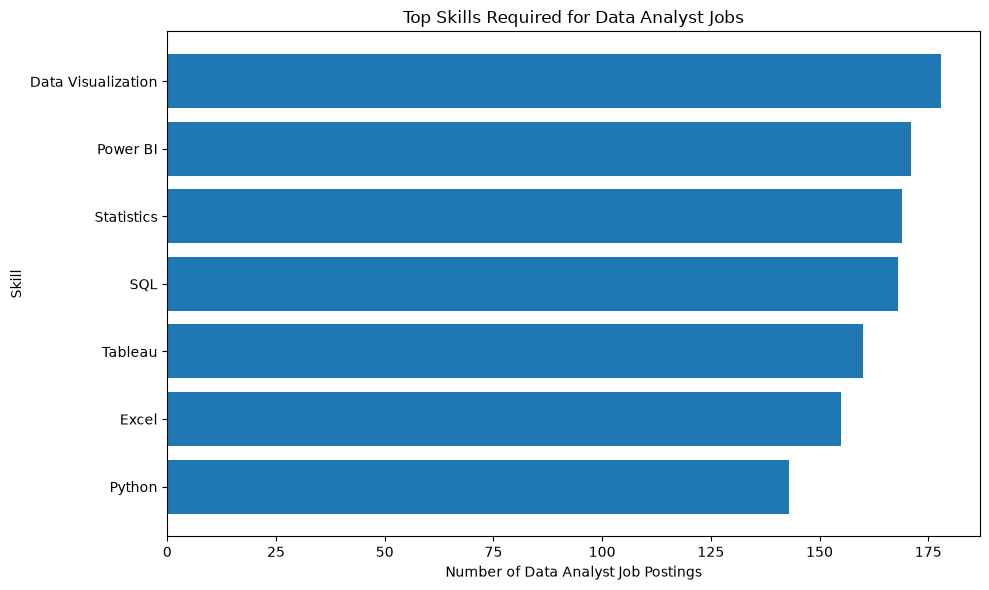

In [7]:
plt.figure(figsize=(10, 6))
plt.barh(
    data_analyst_top_skills["Skill"][::-1],
    data_analyst_top_skills["Job_Count"][::-1]
)
plt.xlabel("Number of Data Analyst Job Postings")
plt.ylabel("Skill")
plt.title("Top Skills Required for Data Analyst Jobs")
plt.tight_layout()
plt.show()

## 6. Data Analyst skills by experience

In [8]:
rows = []

for experience in data_analyst_df["Experience_Level"].dropna().unique():
    counter = Counter()
    subset = data_analyst_df[data_analyst_df["Experience_Level"] == experience]
    for skills in subset["Skills_Required"].dropna():
        counter.update([s.strip() for s in str(skills).split(",") if s.strip()])
    for skill, count in counter.items():
        rows.append([experience, skill, count])

da_experience_skill_df = pd.DataFrame(
    rows, columns=["Experience_Level", "Skill", "Job_Count"]
).sort_values(["Experience_Level", "Job_Count"], ascending=[True, False])

display(da_experience_skill_df)

,Experience_Level,Skill,Job_Count
0,Fresher (0-1 yr),SQL,34
2,Fresher (0-1 yr),Power BI,33
3,Fresher (0-1 yr),Statistics,31
6,Fresher (0-1 yr),Data Visualization,31
5,Fresher (0-1 yr),Python,30
1,Fresher (0-1 yr),Tableau,29
4,Fresher (0-1 yr),Excel,27
28,Junior (1-3 yrs),Power BI,35
29,Junior (1-3 yrs),SQL,34
30,Junior (1-3 yrs),Data Visualization,33


## 7. Skill combinations

In [9]:
pair_counter = Counter()

for skills in df["Skills_Required"].dropna():
    skill_list = sorted(set(s.strip() for s in str(skills).split(",") if s.strip()))
    for pair in combinations(skill_list, 2):
        pair_counter[pair] += 1

skill_pairs_df = pd.DataFrame(
    [[a, b, count] for (a, b), count in pair_counter.most_common(20)],
    columns=["Skill_1", "Skill_2", "Job_Count"]
)

display(skill_pairs_df)

,Skill_1,Skill_2,Job_Count
0,AWS,Docker,422
1,Docker,Python,331
2,AWS,Python,326
3,JavaScript,TypeScript,324
4,Java,REST APIs,315
5,Python,REST APIs,293
6,Excel,SQL,273
7,Excel,Power BI,267
8,Power BI,SQL,263
9,Docker,PostgreSQL,251


## 8. Skills associated with salary

In [10]:
skill_salary_rows = []

for skill in skill_counts:
    mask = df["Skills_Required"].fillna("").apply(
        lambda x: skill in [s.strip() for s in str(x).split(",")]
    )
    subset = df[mask]
    if len(subset) >= 20:
        skill_salary_rows.append([
            skill, len(subset),
            subset["Salary_LPA"].mean(),
            subset["Salary_LPA"].median()
        ])

skill_salary_df = pd.DataFrame(
    skill_salary_rows,
    columns=["Skill", "Job_Count", "Average_Salary_LPA", "Median_Salary_LPA"]
).sort_values("Average_Salary_LPA", ascending=False)

display(skill_salary_df.head(20))

,Skill,Job_Count,Average_Salary_LPA,Median_Salary_LPA
95,Vector DBs,98,26.612245,20.05
103,Machine Learning,96,26.577083,19.00
89,Publications,47,25.676596,19.30
55,Deep Learning,200,25.609500,18.20
82,RAG,82,25.582927,19.45
80,LangChain,80,25.566250,19.05
54,OpenCV,52,25.090385,18.10
81,NLP,235,25.068511,18.40
84,OpenAI API,93,24.606452,14.80
40,Scikit-learn,191,23.815183,15.10


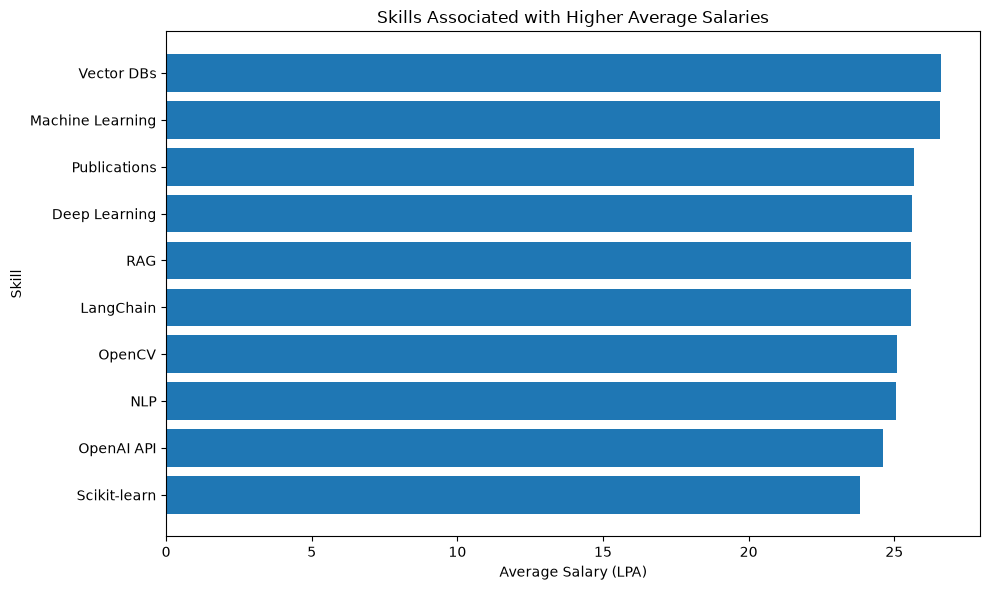

In [11]:
top_salary_skills = skill_salary_df.head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_salary_skills["Skill"][::-1],
    top_salary_skills["Average_Salary_LPA"][::-1]
)
plt.xlabel("Average Salary (LPA)")
plt.ylabel("Skill")
plt.title("Skills Associated with Higher Average Salaries")
plt.tight_layout()
plt.show()

## 9. Data Analyst skill salary analysis

In [12]:
rows = []

for skill in data_analyst_skills:
    mask = data_analyst_df["Skills_Required"].fillna("").apply(
        lambda x: skill in [s.strip() for s in str(x).split(",")]
    )
    subset = data_analyst_df[mask]
    if len(subset) >= 5:
        rows.append([
            skill, len(subset),
            subset["Salary_LPA"].mean(),
            subset["Salary_LPA"].median()
        ])

da_skill_salary_df = pd.DataFrame(
    rows,
    columns=["Skill", "Job_Count", "Average_Salary_LPA", "Median_Salary_LPA"]
).sort_values("Average_Salary_LPA", ascending=False)

display(da_skill_salary_df)

,Skill,Job_Count,Average_Salary_LPA,Median_Salary_LPA
3,Statistics,169,21.407692,17.50
6,Data Visualization,178,20.705056,15.15
4,Excel,155,20.315484,15.40
0,SQL,168,20.221429,13.20
5,Python,143,20.211888,15.00
2,Power BI,171,20.030409,14.80
1,Tableau,160,19.911875,15.10


## 10. Selected skill categories

,Skill_Category,Skill_Mentions
1,Python & Programming,2675
0,SQL & Databases,1718
4,Cloud & Data Engineering,1224
2,BI & Visualization,1033
3,Statistics & ML,955


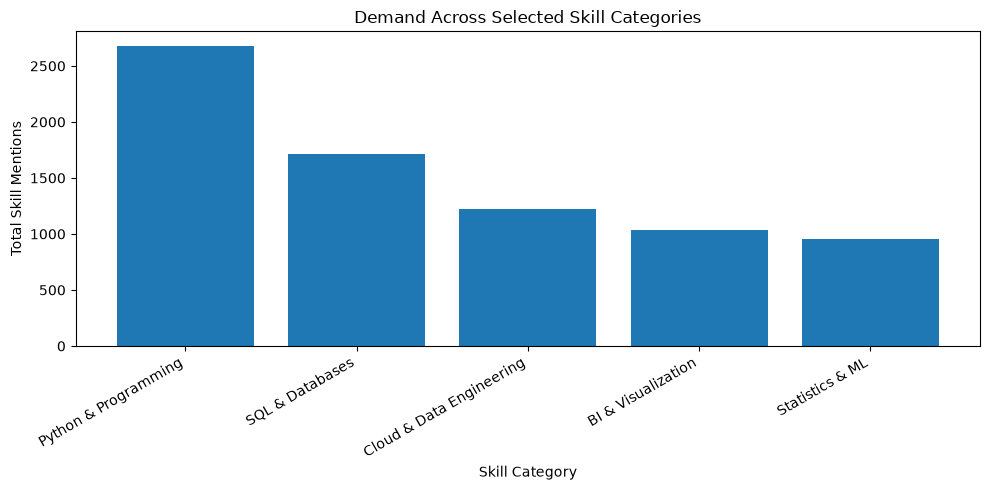

In [13]:
skill_categories = {
    "SQL & Databases": ["SQL", "MySQL", "PostgreSQL", "MongoDB"],
    "Python & Programming": ["Python", "R", "Java", "JavaScript"],
    "BI & Visualization": ["Power BI", "Tableau", "Excel"],
    "Statistics & ML": ["Statistics", "Machine Learning", "TensorFlow", "Scikit-learn"],
    "Cloud & Data Engineering": ["AWS", "Azure", "GCP", "Spark", "Hadoop"]
}

category_df = pd.DataFrame([
    [category, sum(skill_counts.get(skill, 0) for skill in skills)]
    for category, skills in skill_categories.items()
], columns=["Skill_Category", "Skill_Mentions"]).sort_values(
    "Skill_Mentions", ascending=False
)

display(category_df)

plt.figure(figsize=(10, 5))
plt.bar(category_df["Skill_Category"], category_df["Skill_Mentions"])
plt.xlabel("Skill Category")
plt.ylabel("Total Skill Mentions")
plt.title("Demand Across Selected Skill Categories")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 11. Export results for later Power BI use

In [14]:
top_20_skills.to_csv("step5_top_20_skills.csv", index=False)
experience_skill_df.to_csv("step5_skills_by_experience.csv", index=False)
data_analyst_top_skills.to_csv("step5_data_analyst_skills.csv", index=False)
da_experience_skill_df.to_csv("step5_data_analyst_skills_by_experience.csv", index=False)
skill_pairs_df.to_csv("step5_skill_combinations.csv", index=False)
skill_salary_df.to_csv("step5_skill_salary_analysis.csv", index=False)
da_skill_salary_df.to_csv("step5_data_analyst_skill_salary.csv", index=False)
category_df.to_csv("step5_skill_categories.csv", index=False)

print("Step 5 analysis complete.")
print("Result CSV files were saved in the same project folder.")

Step 5 analysis complete.
Result CSV files were saved in the same project folder.


## Interview preparation note

Do not memorize the final findings yet. After Python, SQL, and Power BI are complete, we will build your final explanation around:

**Problem → Dataset → Cleaning → Python → SQL → Power BI → Insights → Limitations → Recommendations.**

The salary-by-skill analysis shows association in this dataset; it should not be described as proof that a skill itself causes higher salary.